In [ ]:
pip install cdsapi

In [ ]:
import cdsapi
c = cdsapi.Client()
print("CDS connection OK")

In [ ]:
conda install -n table_pypsa_env setuptools

In [147]:
import atlite
import xarray as xr

years = [2020, 2021, 2022, 2023, 2024]
months = range(1, 13)

cutouts = []
for year in years:
    for month in months:
        path = f"miso-{year}-{month:02d}.nc"
        cutouts.append(atlite.Cutout(path))

combined = xr.concat([c.data for c in cutouts], dim="time")

INFO:atlite.cutout:Building new cutout miso-2020-01.nc


TypeError: Arguments 'time' and 'module' must be specified. Spatial bounds must either be passed via argument 'bounds' or 'x' and 'y'.

In [ ]:
subprocess.run(["/opt/anaconda3/envs/table_pypsa_env/bin/python", "-m", "pip", "install", "--force-reinstall", "setuptools"], check=True)

In [ ]:
import subprocess
result = subprocess.run(
    ["/opt/anaconda3/envs/table_pypsa_env/bin/python", "-c", "import pkg_resources; print(pkg_resources.__file__)"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

In [ ]:
subprocess.run(["/opt/anaconda3/envs/table_pypsa_env/bin/python", "-m", "pip", "install", "setuptools==69.5.1"], check=True)

In [ ]:
import requests

# Query layer 0 of the FeatureServer with f=geojson
url = (
    "https://services2.arcgis.com/OmhjjQKPQ4s7vrAK/arcgis/rest/services/"
    "MISO_Territory/FeatureServer/0/query"
    "?where=1%3D1&outFields=*&f=geojson"
)

response = requests.get(url)
response.raise_for_status()

with open("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson", "w") as f:
    f.write(response.text)

print("Done")

EPSG:4326
(1, 7)


<AxesSubplot:>

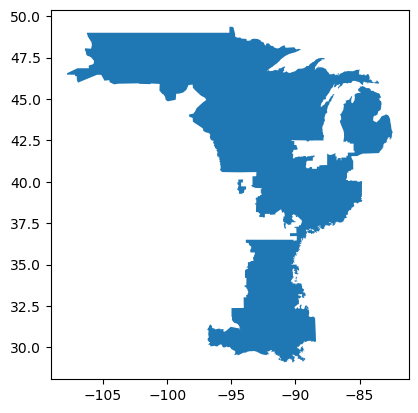

In [144]:
import geopandas as gpd

miso = gpd.read_file("miso_boundary.geojson")
print(miso.crs)
print(miso.shape)
miso.plot()

In [ ]:
import geopandas as gpd

miso = gpd.read_file("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson")
miso = miso.to_crs(5070)

In [ ]:
import xarray as xr
import os

data_dir = "/Users/mshaaban/Miso_Weather_Data"

datasets = []
for year in [2020, 2021, 2022, 2023, 2024]:
    for month in range(1, 13):
        path = os.path.join(data_dir, f"miso-{year}-{month:02d}.nc")
        if os.path.exists(path):
            datasets.append(xr.open_dataset(path))
        else:
            print(f"Skipping missing file: {path}")

combined = xr.concat(datasets, dim="time")
print(combined)

In [ ]:
combined["height"] = combined["height"].isel(time=0).drop_vars("time")

In [ ]:
combined.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_combined_2020_2024.nc")
print("Saved.")

In [ ]:
import requests

url = "https://services3.arcgis.com/fwwoCWVtaahwlvxO/arcgis/rest/services/MISO_Market/FeatureServer/41/query?where=1=1&outFields=*&outSR=4326&f=geojson"

response = requests.get(url)
save_path = "/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson"

with open(save_path, "wb") as f:
    f.write(response.content)

print("Saved to", save_path)

In [ ]:
import geopandas as gpd

miso = gpd.read_file("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson")
miso = miso.to_crs(5070)
print(miso.crs)
print(miso.shape)
print(miso.columns.tolist())

In [ ]:
from atlite.gis import ExclusionContainer

miso = gpd.read_file("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson")
miso = miso.to_crs(5070)

excluder = ExclusionContainer(crs=5070, res=1000)

A = cutout.availabilitymatrix(miso, excluder)
print(A)

In [ ]:
import numpy as np

area = cutout.grid.set_index(["y", "x"]).to_crs(5070).area / 1e6  # km²
area = xr.DataArray(area, dims=("spatial",))

cap_per_sqkm_wind = 2   # MW/km² for wind
cap_per_sqkm_solar = 40  # MW/km² for solar

capacity_matrix_wind  = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_wind
capacity_matrix_solar = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_solar

print(capacity_matrix_wind)

In [ ]:
import numpy as np

# Add temperature as a scalar that broadcasts
cutout.data["temperature"] = xr.DataArray(25.0)

solar_cf = cutout.pv(
    panel="CSi",
    orientation={"slope": 30.0, "azimuth": 180.0},
    matrix=capacity_matrix_solar,
    index=miso.index,
)
print("Solar done")
print(solar_cf)

In [ ]:
wind_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_wind_cf_2020_2024.nc")
solar_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc")
print("Saved.")

In [ ]:
# Find which zones have data
active_zones = int((w != 0).any(dim='time').sum())
active_mask = (w != 0).any(dim='time')
print('Active zone indices:', active_mask.values.nonzero()[0].tolist())

In [ ]:
from atlite.gis import ExclusionContainer

excluder = ExclusionContainer(crs=5070, res=1000)
A = cutouts[0].availabilitymatrix(miso, excluder)  # use one cutout to get the matrix shape

In [ ]:
import xarray as xr

cutouts = [atlite.Cutout(f"miso-{year}-{month:02d}.nc") for year in years for month in range(1, 13)]
combined = xr.concat([c.data for c in cutouts], dim="time")

In [ ]:
import atlite, calendar

years = [2020, 2021, 2022, 2023, 2024]

cutouts = []
for year in years:
    for month in range(1, 13):
        last_day = calendar.monthrange(year, month)[1]
        cutout = atlite.Cutout(
            path=f"/Users/mshaaban/Miso_Weather_Data/miso-{year}-{month:02d}.nc",
            module="era5",
            x=slice(-105, -82),
            y=slice(28, 50),
            time=slice(f"{year}-{month:02d}-01", f"{year}-{month:02d}-{last_day}"),
        )
        cutouts.append(cutout)

print(f"Loaded {len(cutouts)} cutouts")

In [ ]:
import geopandas as gpd
from atlite.gis import ExclusionContainer

miso = gpd.read_file("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson")
miso = miso.to_crs(5070)

excluder = ExclusionContainer(crs=5070, res=1000)
A = cutouts[0].availabilitymatrix(miso, excluder)
print(A)

In [ ]:
import requests

url = (
    "https://services2.arcgis.com/OmhjjQKPQ4s7vrAK/arcgis/rest/services/"
    "MISO_Territory/FeatureServer/0/query"
    "?where=1%3D1&outFields=*&f=geojson"
)

response = requests.get(url)
response.raise_for_status()

with open("/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson", "w") as f:
    f.write(response.text)

print("Done")

In [ ]:
import xarray as xr
import numpy as np

area = cutouts[0].grid.set_index(["y", "x"]).to_crs(5070).area / 1e6  # km²
area = xr.DataArray(area, dims=("spatial",))

cap_per_sqkm_wind  = 2    # MW/km²
cap_per_sqkm_solar = 40   # MW/km²

capacity_matrix_wind  = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_wind
capacity_matrix_solar = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_solar

print(capacity_matrix_wind)

In [ ]:
# Wind
wind_cf = cutouts[0].wind(
    turbine="Vestas_V112_3MW",
    matrix=capacity_matrix_wind,
    index=miso.index,
)
print("Wind done")
print(wind_cf)

# Solar
solar_cf = cutouts[0].pv(
    panel="CSi",
    orientation={"slope": 30.0, "azimuth": 180.0},
    matrix=capacity_matrix_solar,
    index=miso.index,
)
print("Solar done")
print(solar_cf)

In [ ]:
wind_all = []
solar_all = []

for i, cutout in enumerate(cutouts):
    # Skip empty cutouts
    if len(cutout.data.data_vars) == 0:
        print(f"Skipping empty cutout {i}")
        continue

    area = cutout.grid.set_index(["y", "x"]).to_crs(5070).area / 1e6
    area = xr.DataArray(area, dims=("spatial",))

    cap_wind  = A.stack(spatial=["y", "x"]) * area * 2
    cap_solar = A.stack(spatial=["y", "x"]) * area * 40

    w = cutout.wind(
        turbine="Vestas_V112_3MW",
        matrix=cap_wind,
        index=miso.index,
    )

    cutout.data["temperature"] = xr.full_like(cutout.data["influx_direct"], 25.0)
    s = cutout.pv(
        panel="CSi",
        orientation={"slope": 30.0, "azimuth": 180.0},
        matrix=cap_solar,
        index=miso.index,
    )

    wind_all.append(w.load())
    solar_all.append(s.load())
    print(f"Done {i+1}/60")

wind_cf = xr.concat(wind_all, dim="time")
solar_cf = xr.concat(solar_all, dim="time")

wind_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_wind_cf_2020_2024.nc")
solar_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc")
print("Saved.")

In [ ]:
import numpy as np

area = cutouts[0].grid.set_index(["y", "x"]).to_crs(5070).area / 1e6  # km²
area = xr.DataArray(area, dims=("spatial",))

cap_per_sqkm_wind  = 2    # MW/km²
cap_per_sqkm_solar = 40   # MW/km²

capacity_matrix_wind  = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_wind
capacity_matrix_solar = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm_solar

In [ ]:
# Wind
wind_cf = cutouts[0].wind(
    turbine="Vestas_V112_3MW",
    matrix=capacity_matrix_wind,
    index=miso.index,
)

# Solar
cutouts[0].data["temperature"] = xr.DataArray(25.0)
solar_cf = cutouts[0].pv(
    panel="CSi",
    orientation={"slope": 30.0, "azimuth": 180.0},
    matrix=capacity_matrix_solar,
    index=miso.index,
)

In [ ]:
wind_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_wind_cf_2020_2024.nc")
solar_cf.to_netcdf("/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc")
print("Saved.")

In [ ]:

import logging
import warnings

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from cartopy.crs import PlateCarree as plate
from matplotlib.gridspec import GridSpec
from pandas.plotting import register_matplotlib_converters

import atlite

register_matplotlib_converters()
warnings.simplefilter("ignore")
logging.captureWarnings(False)
logging.basicConfig(level=logging.INFO)

In [ ]:
projection = ccrs.Orthographic(280, 20)

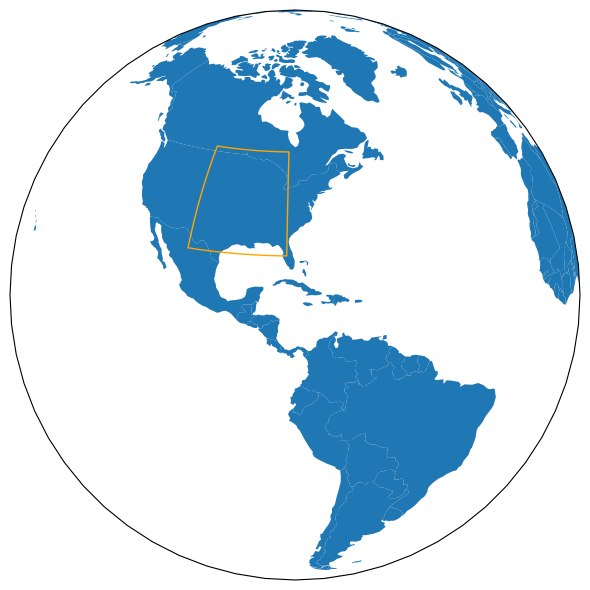

In [148]:
cells = cutout.grid
url = (
    "zip+https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
df = gpd.read_file(url)
country_bound = gpd.GeoSeries(cells.union_all())

projection = ccrs.Orthographic(280, 20)
fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(6, 6))
df.plot(ax=ax, transform=plate())
country_bound.plot(ax=ax, edgecolor="orange", facecolor="None", transform=plate())
fig.tight_layout()

<xarray.DataArray 'specific generation' (time: 744, dim_0: 1)> Size: 6kB
[744 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * dim_0    (dim_0) int64 8B 0
Attributes:
    units:    MW


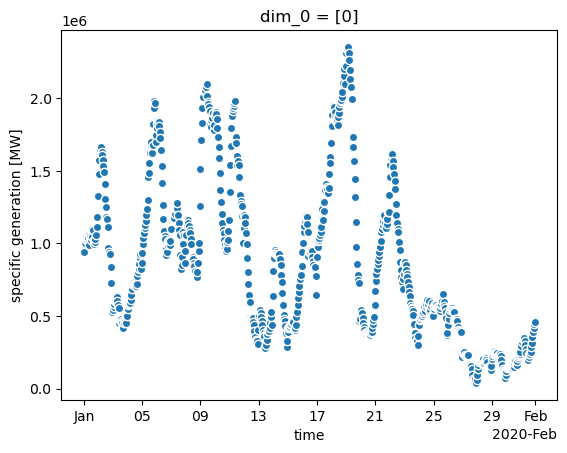

In [145]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso_wind_cf_2020_2024.nc')
print(data['specific generation'])

xr.plot.scatter(data, x="time", y="specific generation")

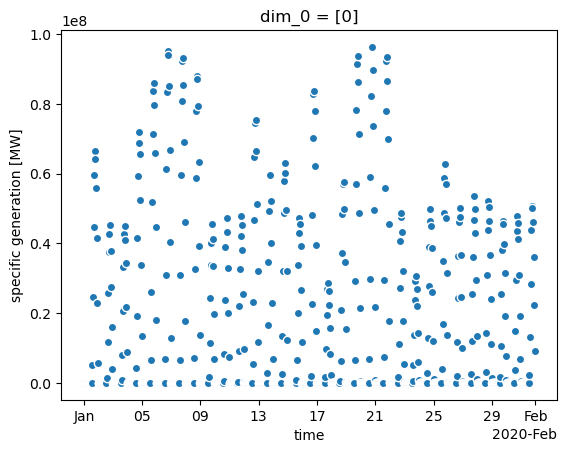

In [146]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc')
#print(data['specific generation'])

xr.plot.scatter(data, x="time", y="specific generation")

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/miso_solar_cf_2020_2024.nc')
#print(data['specific generation'])

xr.plot.scatter(data, x="time", y="specific generation")

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/miso_wind_cf_2020_2024.nc')
print(data['specific generation'])

xr.plot.scatter(data, x="time", y="specific generation")

In [ ]:
import xarray as xr
import pandas as pd

solar = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc')
w = solar['specific generation']

# How many zones are all zeros?
all_zero_zones = int((w == 0).all(dim='time').sum())
print(f'Zones with all zeros: {all_zero_zones} out of 224')

In [ ]:
import xarray as xr
import pandas as pd

wind = xr.open_dataset('/Users/mshaaban/miso_wind_cf_2020_2024.nc')
w = wind['specific generation']

# How many zones are all zeros?
all_zero_zones = int((w == 0).all(dim='time').sum())
print(f'Zones with all zeros: {all_zero_zones} out of 224')

In [ ]:
import xarray as xr
import pandas as pd

solar = xr.open_dataset('/Users/mshaaban/miso_solar_cf_2020_2024.nc')
w = solar['specific generation']

# How many zones are all zeros?
all_zero_zones = int((w == 0).all(dim='time').sum())
print(f'Zones with all zeros: {all_zero_zones} out of 224')

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso_wind_cf_2020_2024.nc')

df = data.to_dataframe()
print(df)

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso_solar_cf_2020_2024.nc')

df = data.to_dataframe()
print(df)

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/miso_solar_cf_2020_2024.nc')

df = data.to_dataframe()
print(df)

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/miso_solar_cf_2020_2024.nc')

df = data.to_dataframe()
print(df)

In [ ]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Weather_within_MISO/miso-test-2020-01.nc')

df = data.to_dataframe()
#print(df)

df.to_csv("/Users/mshaaban/Weather_within_MISO/miso-test-2020-01.csv", index=False)
print("Saved to CSV.")

Saved to CSV.


In [ ]:
print(cutouts[0].data)

In [ ]:
for i, cutout in enumerate(cutouts[:]):
    print(f"\nCutout {i} variables:", list(cutout.data.data_vars))

In [139]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/Miso_Weather_Data/miso-2024-11.nc')
print(data)

#xr.plot.scatter(data, x="time", y="specific generation")

<xarray.Dataset> Size: 262MB
Dimensions:         (x: 93, y: 89, time: 720)
Coordinates:
  * x               (x) float64 744B -105.0 -104.8 -104.5 ... -82.5 -82.25 -82.0
  * y               (y) float64 712B 28.0 28.25 28.5 28.75 ... 49.5 49.75 50.0
  * time            (time) datetime64[ns] 6kB 2024-11-01 ... 2024-11-30T23:00:00
    lon             (x) float64 744B ...
    lat             (y) float64 712B ...
Data variables:
    wnd100m         (time, y, x) float32 24MB ...
    wnd_azimuth     (time, y, x) float32 24MB ...
    roughness       (time, y, x) float32 24MB ...
    influx_toa      (time, y, x) float32 24MB ...
    influx_direct   (time, y, x) float32 24MB ...
    influx_diffuse  (time, y, x) float32 24MB ...
    albedo          (time, y, x) float32 24MB ...
    solar_altitude  (time, y, x) float64 48MB ...
    solar_azimuth   (time, y, x) float64 48MB ...
    height          (y, x) float32 33kB ...
Attributes:
    module:                  era5
    prepared_features:       ['in